<a href="https://colab.research.google.com/github/2303A54061/HPC-PROJECT-Parallel-Weather-Data-Analysis-using-Parallelization-/blob/main/HPC_PROJECT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Realistic Seasonal Weather Dataset**

In [ ]:
import csv
import random
from datetime import datetime, timedelta

rows = 1200
start_date = datetime(2020, 1, 1)

def seasonal_weather(month):
    # Winter (Nov–Feb)
    if month in [11, 12, 1, 2]:
        temp = random.uniform(20, 30)
        humidity = random.uniform(50, 70)
        rainfall = random.uniform(0, 5)

    # Summer (Mar–Jun)
    elif month in [3, 4, 5, 6]:
        temp = random.uniform(30, 45)
        humidity = random.uniform(40, 65)
        rainfall = random.uniform(0, 3)

    # Monsoon (Jul–Sep)
    elif month in [7, 8, 9]:
        temp = random.uniform(25, 35)
        humidity = random.uniform(70, 95)
        rainfall = random.uniform(5, 20)

    # Post-monsoon (Oct)
    else:
        temp = random.uniform(25, 33)
        humidity = random.uniform(60, 80)
        rainfall = random.uniform(1, 10)

    windspeed = random.uniform(5, 20)

    return round(temp,1), round(humidity,1), round(rainfall,1), round(windspeed,1)

with open("weather_seasonal.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Date","Temperature","Humidity","Rainfall","WindSpeed"])

    for i in range(rows):
        date = start_date + timedelta(days=i)
        t, h, r, w = seasonal_weather(date.month)
        writer.writerow([date.strftime("%Y-%m-%d"), t, h, r, w])

print("Seasonal dataset generated!")

Seasonal dataset generated!


**Temperature Trend**

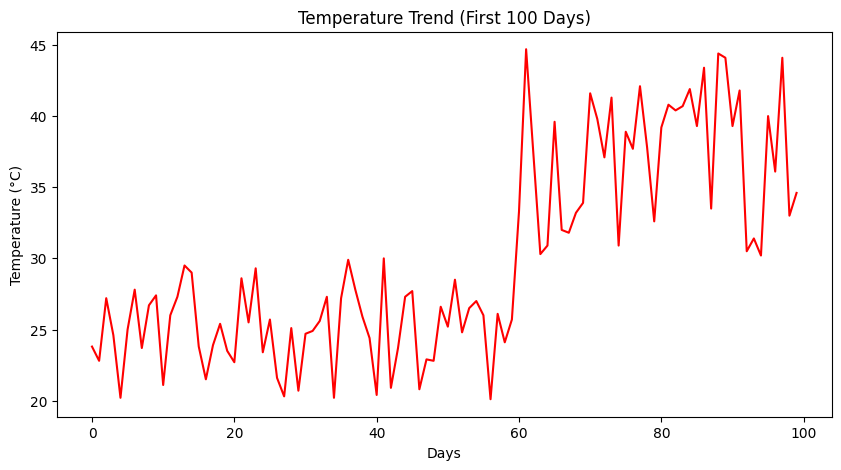

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("weather_seasonal.csv")

plt.figure(figsize=(10,5))
plt.plot(data["Temperature"][:100], color='red')
plt.title("Temperature Trend (First 100 Days)")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.show()

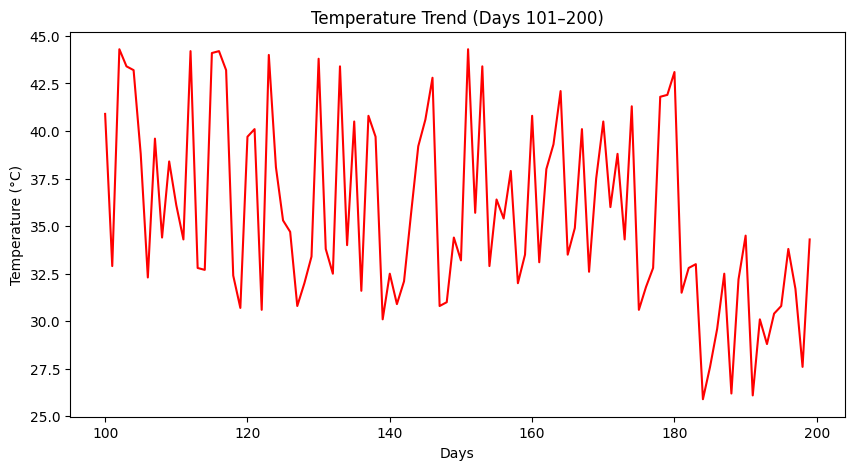

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("weather_seasonal.csv")

plt.figure(figsize=(10,5))
plt.plot(data["Temperature"][100:200], color='red')
plt.title("Temperature Trend (Days 101–200)")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.show()


**Rainfall Pattern (Shows Monsoon)**

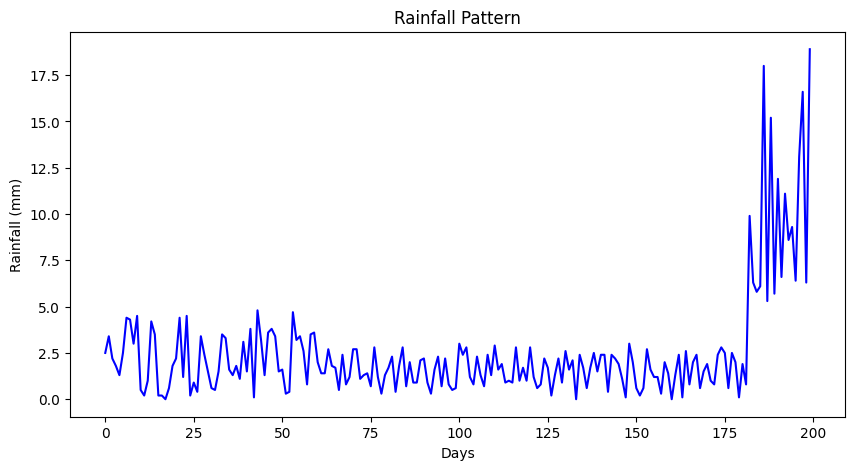

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data["Rainfall"][:200], color='blue')
plt.title("Rainfall Pattern")
plt.xlabel("Days")
plt.ylabel("Rainfall (mm)")
plt.show()

**Monthly Average Temperature**

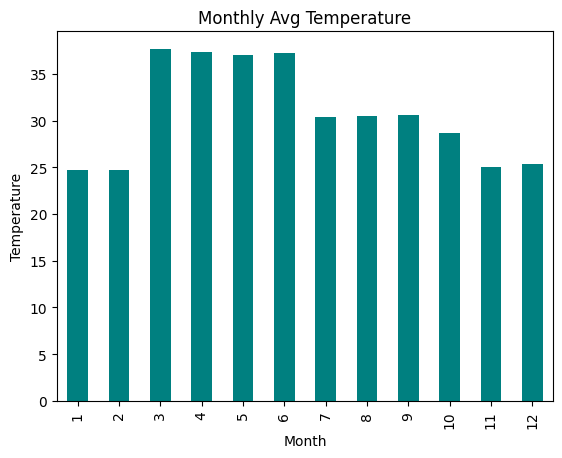

In [ ]:
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.month

monthly_avg = data.groupby("Month")["Temperature"].mean()

monthly_avg.plot(kind='bar', color='teal')
plt.title("Monthly Avg Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

**Plotting Temperature for Specific Months**

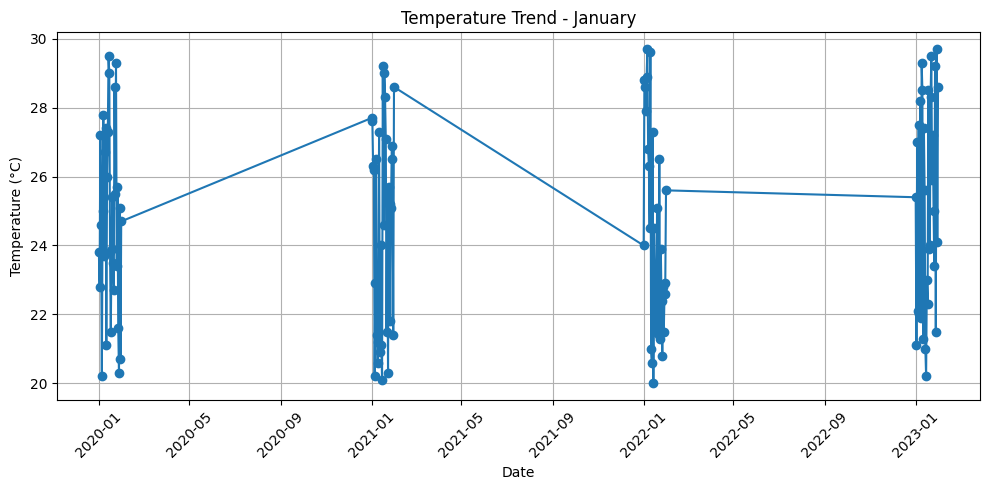

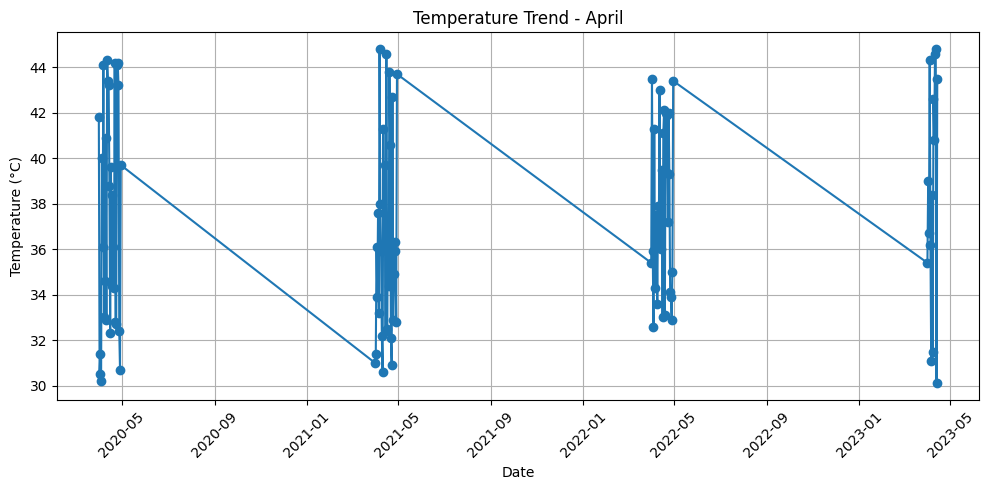

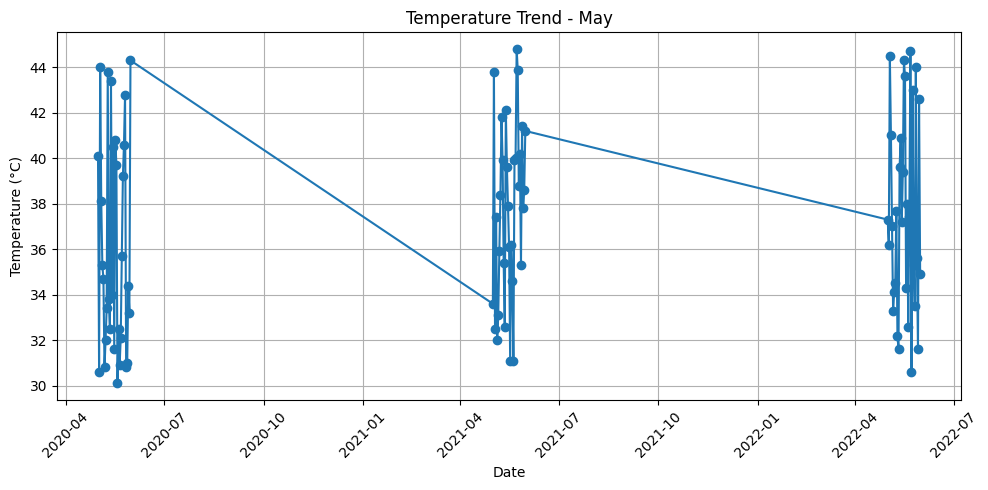

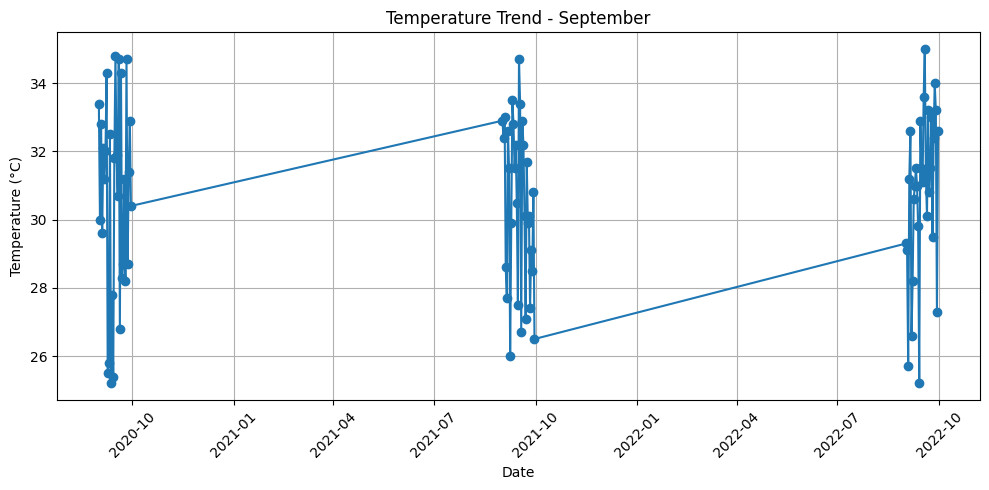

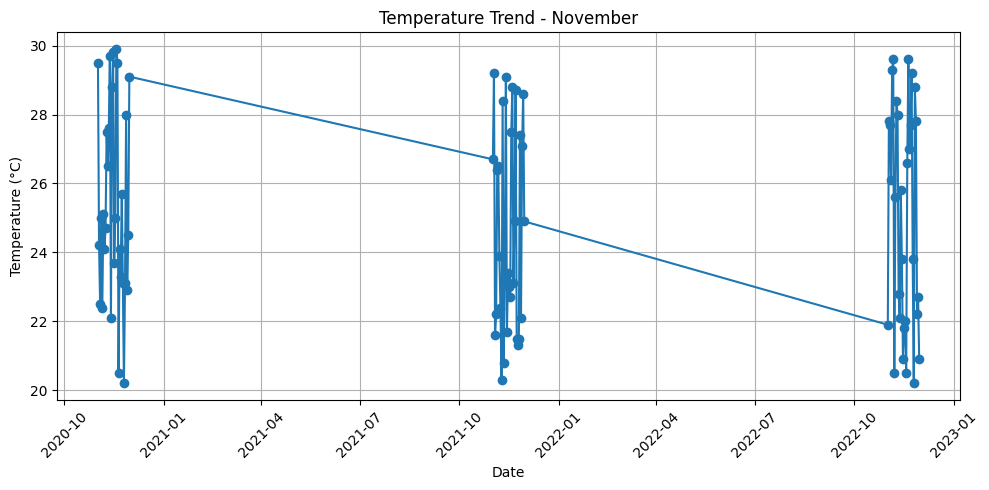

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("weather_seasonal.csv")

# Convert Date column to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Extract Month Name
data["Month_Name"] = data["Date"].dt.strftime('%B')

# List of required months
months_to_plot = ["January", "April", "May", "September", "November"]

# Plot each month separately
for month in months_to_plot:
    month_data = data[data["Month_Name"] == month]

    plt.figure(figsize=(10,5))
    plt.plot(month_data["Date"], month_data["Temperature"], marker='o')
    plt.title(f"Temperature Trend - {month}")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Parallel vs Sequential Time Graph**

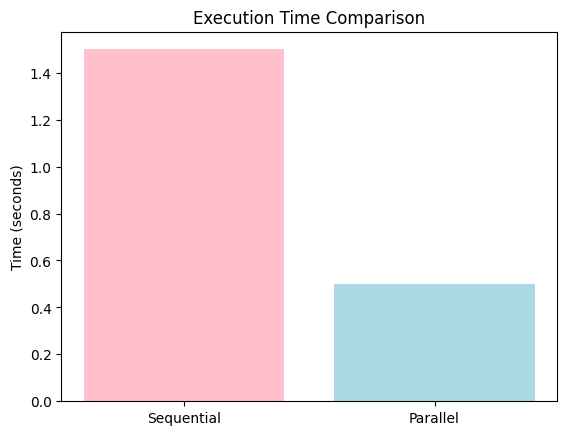

In [ ]:
methods = ["Sequential", "Parallel"]
times = [1.5, 0.5]

plt.bar(methods, times, color=['Pink','lightblue'])
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()

**Monthly Weather Analysis: Temperature vs Rainfall**

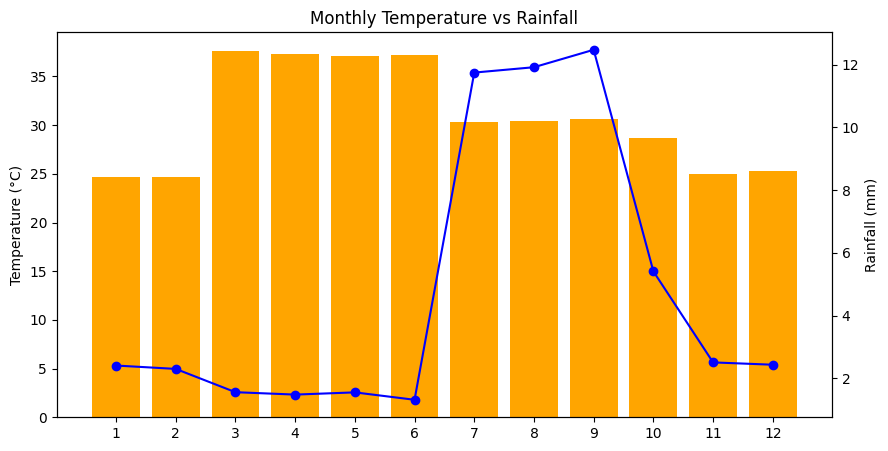

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("weather_seasonal.csv")

# Create Month column
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.month

# ✅ Create required variables
monthly_temp = data.groupby("Month")["Temperature"].mean()
monthly_rain = data.groupby("Month")["Rainfall"].mean()

# Plot
fig, ax1 = plt.subplots(figsize=(10,5))

# Temperature (bar)
ax1.bar(monthly_temp.index, monthly_temp.values, color='orange')
ax1.set_ylabel("Temperature (°C)")

# Rainfall (line)
ax2 = ax1.twinx()
ax2.plot(monthly_rain.index, monthly_rain.values, color='blue', marker='o')
ax2.set_ylabel("Rainfall (mm)")

plt.title("Monthly Temperature vs Rainfall")
plt.xticks(range(1,13))
plt.show()